<div style="background:#FFF5F8;border:3px solid #E0218A;border-radius:16px;padding:28px;text-align:center;">
<h1 style="color:#E0218A;margin:0;">🐥 Curso de Machine Learning · Clase 1 de 7</h1>
<h2 style="color:#1B2A5B;margin:10px 0 4px;">Tu primera predicción, ¿a quién le presta PolliCreditos?</h2>
<p style="color:#1B2A5B;margin:6px 0;">Con la Miss Yera · <a href="https://missyera.com">missyera.com</a> · @soymissyera</p>
<p style="color:#E0218A;margin:0;"><b>Regla de oro del curso, nadie ejecuta una celda sin predecir en voz alta qué va a pasar.</b></p>
</div>

## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥▫️▫️▫️▫️▫️▫️ · clase 1 de 7

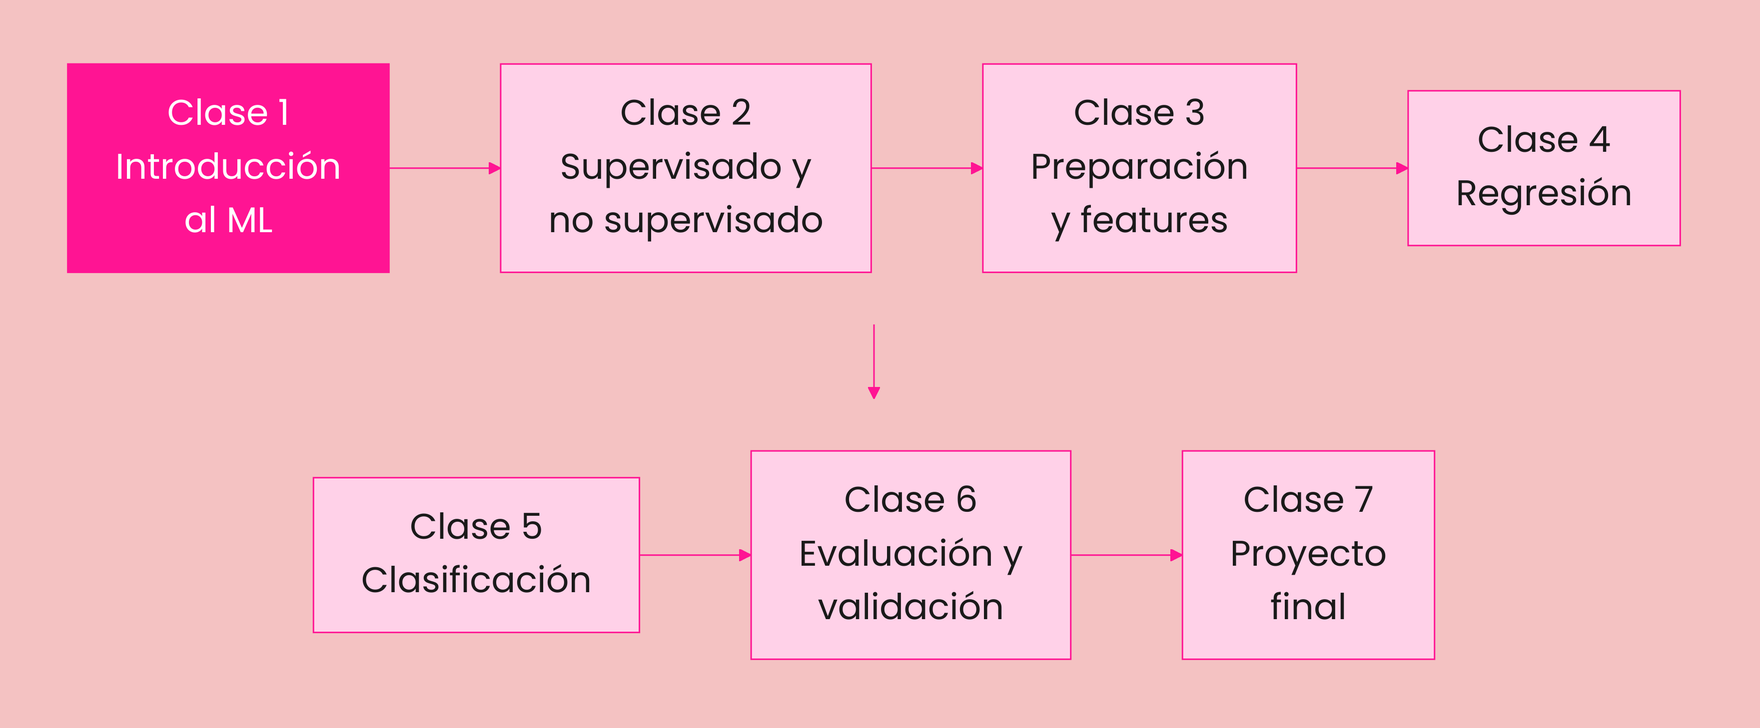


## 🎯 Lo que vas a lograr hoy

- Entender qué significa que una máquina aprenda de datos y en qué se diferencia de programar reglas a mano.
- Ubicar el machine learning en el mapa de la inteligencia artificial sin perderse en la jerga.
- Reconocer los ingredientes de todo problema de ML, los datos X, la respuesta y, y el modelo.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><i>"Soy el CEO de PolliCreditos y cada semana llegan 200 solicitudes de crédito que evaluamos a ojo. Tenemos la historia de quién pagó y quién no. ¿Puedes construir algo que aprenda de esa historia?"</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>



<div style="background: linear-gradient(135deg, #FF1493 0%, #FF69B4 55%, #FFB6C1 100%); border-radius: 22px; padding: 42px 36px; text-align: center; color: white; font-family: 'Inter', sans-serif;">
  <div style="font-size: 15px; letter-spacing: 3px; opacity: .95;">🐤 CURSO DE MACHINE LEARNING · CLASE 01</div>
  <h1 style="margin: 14px 0 6px 0; font-size: 40px; color: white;">Introducción al machine learning</h1>
  <div style="font-size: 18px; opacity: .96;">Cuando las máquinas aprenden de los datos en vez de seguir reglas</div>
  <div style="margin-top: 22px; font-size: 14px; background: rgba(255,255,255,.18); display: inline-block; padding: 8px 20px; border-radius: 999px;">Miss Yera · missyera.com · @soymissyera</div>
</div>



<div style="background: #FFF5F8; border-left: 6px solid #FF1493; border-radius: 14px; padding: 20px 24px;">
<b style="color:#FF1493;">👩‍🏫 ¿Quién te enseña hoy?</b><br><br>
Soy <b>Yera Flores, la Miss Yera</b>. Llevo más de trece años trabajando con datos, analítica e inteligencia artificial de verdad, resolviendo problemas reales con código real. Enseño como me hubiera gustado que me enseñaran a mí, con ejemplos concretos, sin humo y celebrando cada logro.<br><br>
Mi comunidad se llama <b>pollitos</b> 🐥 y hoy tú eres parte de ella. Regla de oro de mi clase, nadie ejecuta una celda sin antes predecir en voz alta qué va a pasar.
</div>



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 17px;">🎯 Al final de esta clase vas a poder</b>
<ul style="margin-top: 10px;"><li>Explicar qué es machine learning y en qué se diferencia de programar reglas</li>
<li>Ubicar el ML dentro del mapa de la inteligencia artificial</li>
<li>Reconocer los ingredientes de todo problema de ML, datos, features y target</li>
<li>Ver un modelo real aprendiendo en vivo, tu primer fit y predict</li>
<li>Identificar casos de uso reales en Perú y el mundo</li></ul>
</div>


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')

Setup listo, pollito 🐥


## 1. La demo wow, un modelo dicta veredicto antes de explicar nada

Regla de oro de mi clase, primero lo ves funcionar, después entendemos por qué. Este modelo va a aprender a distinguir clientes que pagan su préstamo de los que no, mirando solo ejemplos históricos. Nadie le programa reglas.

In [2]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)

# Historia crediticia de 200 clientes de PolliCreditos, ingreso mensual y deuda actual
n = 200
ingreso = np.random.uniform(1000, 8000, n)
deuda = np.random.uniform(0, 6000, n)
# La verdad oculta que el modelo debe descubrir, paga quien debe poco frente a su ingreso
paga = (deuda / ingreso < 0.75).astype(int)
# Un poco de ruido humano, la vida real nunca es perfecta
ruido = np.random.rand(n) < 0.08
paga[ruido] = 1 - paga[ruido]

X = np.column_stack([ingreso, deuda])
modelo = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo.fit(X, paga)                       # el modelo APRENDE de los ejemplos

# Veredicto en vivo para dos clientes nuevos que jamás vio
clientes_nuevos = np.array([[5000, 1000], [2000, 3500]])
veredictos = modelo.predict(clientes_nuevos)
for (ing, deu), v in zip(clientes_nuevos, veredictos):
    print(f"Cliente con ingreso S/ {ing:,.0f} y deuda S/ {deu:,.0f} → {'✅ pagará' if v == 1 else '❌ riesgo de impago'}")

Cliente con ingreso S/ 5,000 y deuda S/ 1,000 → ✅ pagará
Cliente con ingreso S/ 2,000 y deuda S/ 3,500 → ❌ riesgo de impago



<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Qué acaba de pasar?</b><br>
Nadie escribió la regla deuda entre ingreso menor a 0.75. El modelo la descubrió solo mirando 200 ejemplos. Eso es machine learning, en vez de programar las reglas, le das ejemplos y la máquina encuentra los patrones.
</div>



<div style="background: #FFF5F8; border: 2px dashed #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#1B2A5B; font-size: 16px;">📖 Concepto nuevo, <span style="color:#FF1493;">Machine learning</span></b><br>
Es la rama de la inteligencia artificial donde los programas aprenden patrones a partir de datos, en lugar de seguir reglas escritas a mano por un humano.<br>
<i>🐥 En idioma pollito, El pollito que aprende. No le das un manual de qué comer, le muestras mil ejemplos de comida buena y mala, y él solo aprende a distinguir.</i>
</div>


## 2. El mapa, dónde vive el ML

```text
INTELIGENCIA ARTIFICIAL          máquinas que hacen tareas inteligentes
 └── MACHINE LEARNING            aprenden patrones desde datos
      ├── Supervisado            aprenden con ejemplos etiquetados      ← nuestro foco
      ├── No supervisado         encuentran estructura sin etiquetas
      └── Por refuerzo           aprenden por prueba, error y premio
           └── DEEP LEARNING     redes neuronales profundas, atraviesa las tres ramas
```

Los chatbots como ChatGPT y Claude son deep learning entrenado sobre texto, primos sofisticados de lo que vamos a construir en este curso.

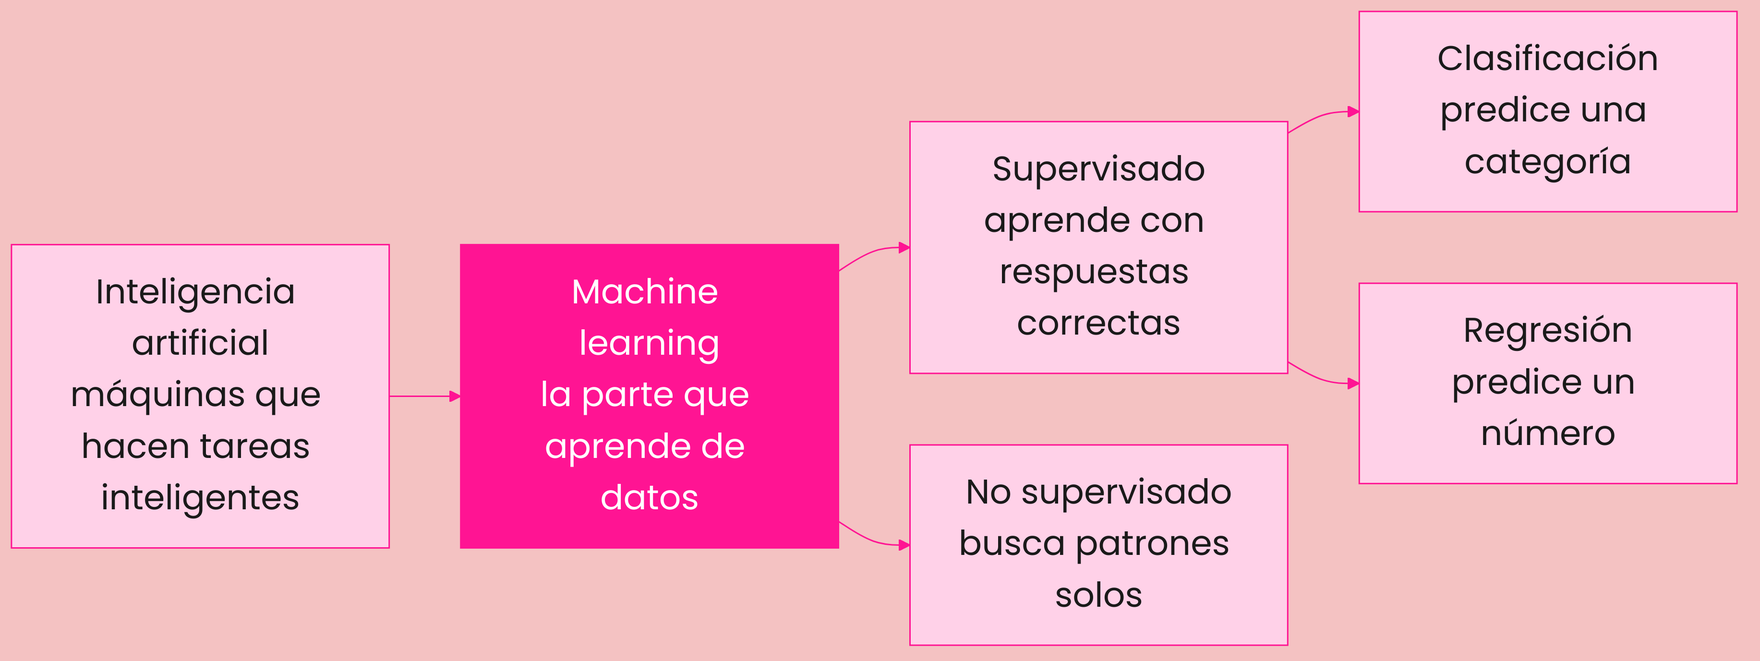

*El machine learning es la parte de la IA que aprende de datos, y hoy vives aquí.*


## 3. Reglas contra datos, el concepto madre

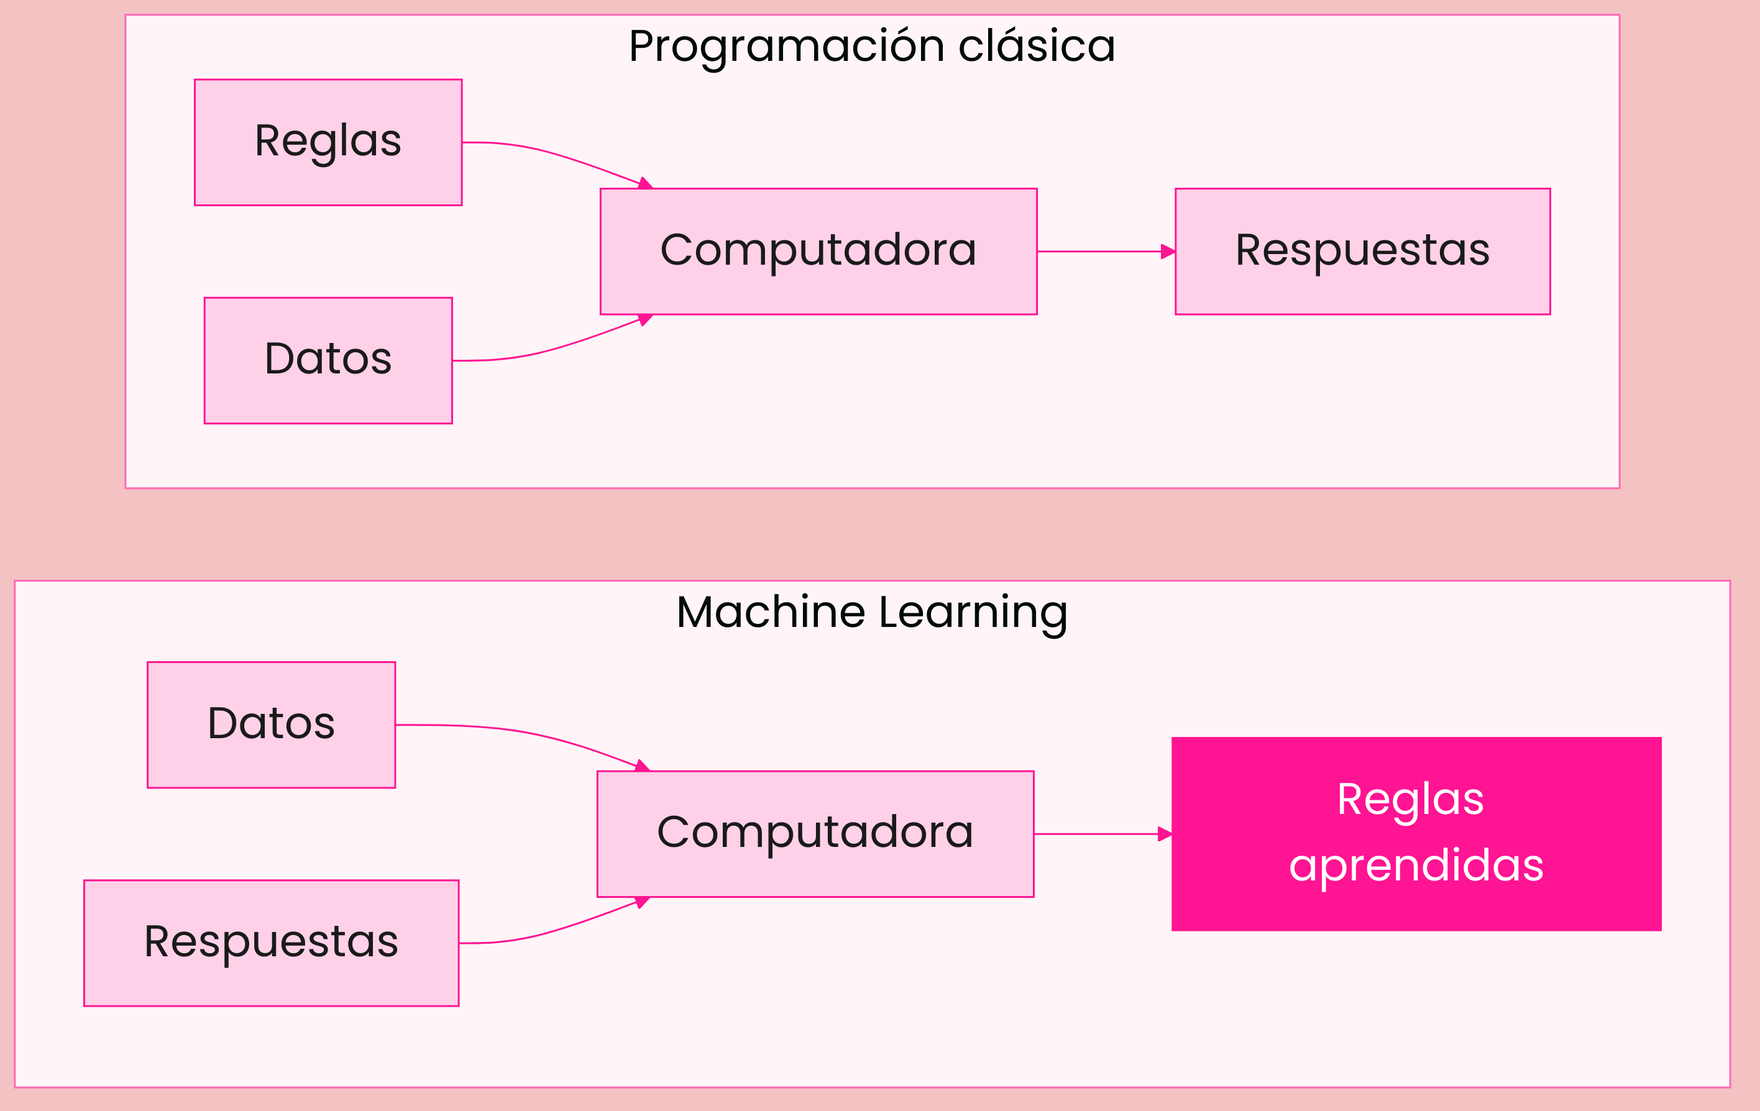

*La programación clásica recibe reglas y datos, el ML recibe datos y respuestas, y devuelve las reglas.*


In [3]:
# ENFOQUE 1, reglas escritas a mano, el mundo antes del ML
def aprobar_prestamo_con_reglas(ingreso, deuda):
    if ingreso > 3000 and deuda < 2000:
        return "aprobado"
    return "rechazado"

# ENFOQUE 2, el modelo que ya aprendió de los datos
def aprobar_prestamo_con_ml(ingreso, deuda):
    return "aprobado" if modelo.predict([[ingreso, deuda]])[0] == 1 else "rechazado"

# Caso interesante, ingreso alto con deuda moderada
caso = (7000, 2500)
print("Con reglas fijas,", aprobar_prestamo_con_reglas(*caso))
print("Con ML,          ", aprobar_prestamo_con_ml(*caso))

Con reglas fijas, rechazado
Con ML,           aprobado



<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de esta celda</b><br>
La regla fija rechaza a un excelente cliente porque su deuda supera un umbral arbitrario de 2000, sin mirar que gana 7000. El modelo aprendió la relación entre las variables y aprueba. Las reglas manuales se quiebran con la complejidad, los datos la capturan.
</div>


## 4. Los ingredientes de todo problema de ML

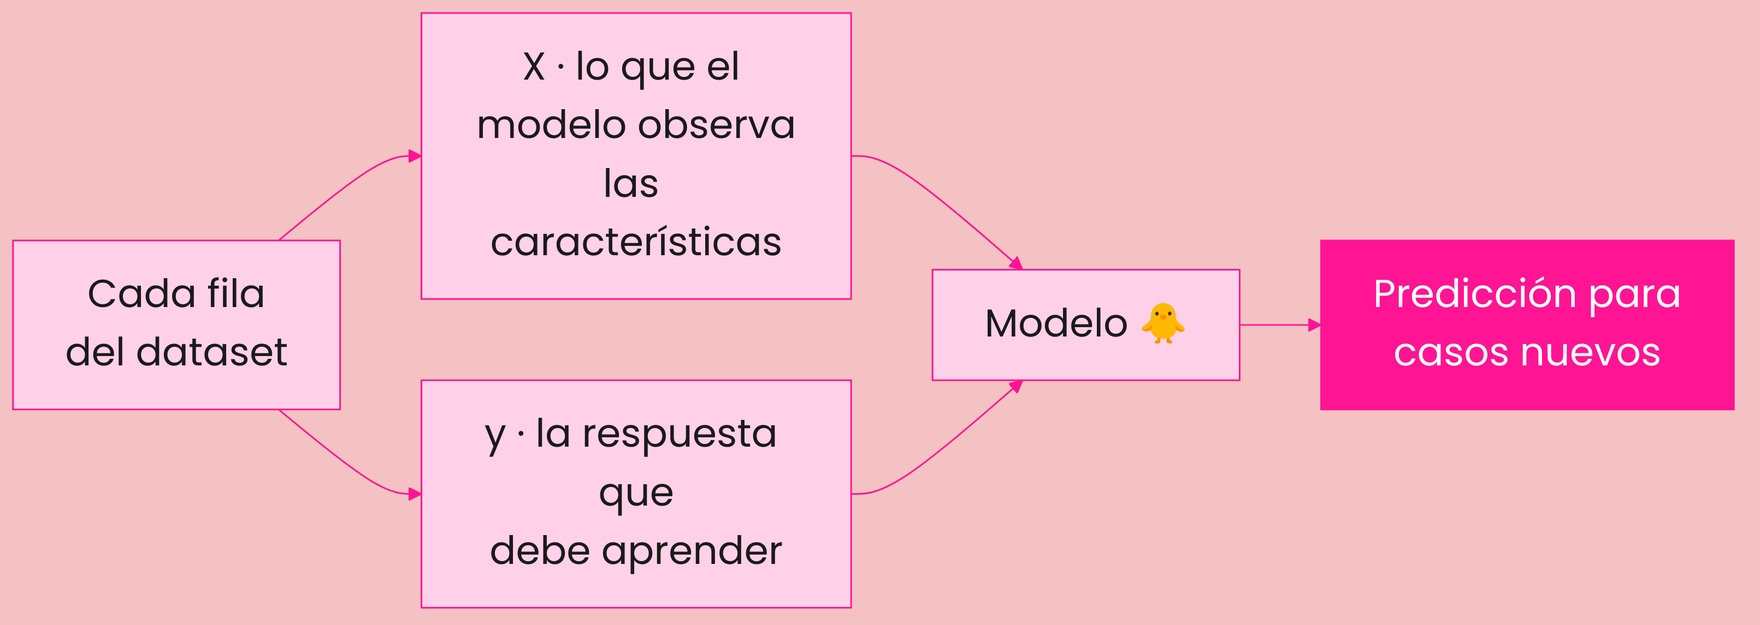

*Todo problema de ML se arma con lo que el modelo observa, X, y la respuesta que debe aprender, y.*


In [4]:
import pandas as pd

tabla = pd.DataFrame(X[:5], columns=["ingreso", "deuda"])
tabla["paga (target)"] = paga[:5]
print(tabla.round(0))
print(f"""
📊 FEATURES (X)     las columnas con las que predecimos, ingreso y deuda
🎯 TARGET (y)       la columna que queremos predecir, paga o no paga
📚 EJEMPLOS         cada fila es una experiencia de la que el modelo aprende
🤖 MODELO           la máquina que conecta features con target
""")

   ingreso   deuda  paga (target)
0   3622.0  3852.0              0
1   7655.0   505.0              1
2   6124.0   970.0              1
3   5191.0  5391.0              0
4   2092.0  3639.0              0

📊 FEATURES (X)     las columnas con las que predecimos, ingreso y deuda
🎯 TARGET (y)       la columna que queremos predecir, paga o no paga
📚 EJEMPLOS         cada fila es una experiencia de la que el modelo aprende
🤖 MODELO           la máquina que conecta features con target



## 5. Visualizando lo que el modelo aprendió

### 🧮 La matemática detrás · Funciones y vectores, álgebra lineal

$\hat{y} = f(x_1, x_2, ..., x_n)$

**Lectura en palabras,** el modelo entero es una función, entran las características de la fila y sale una predicción, entrenar es encontrar esa f.

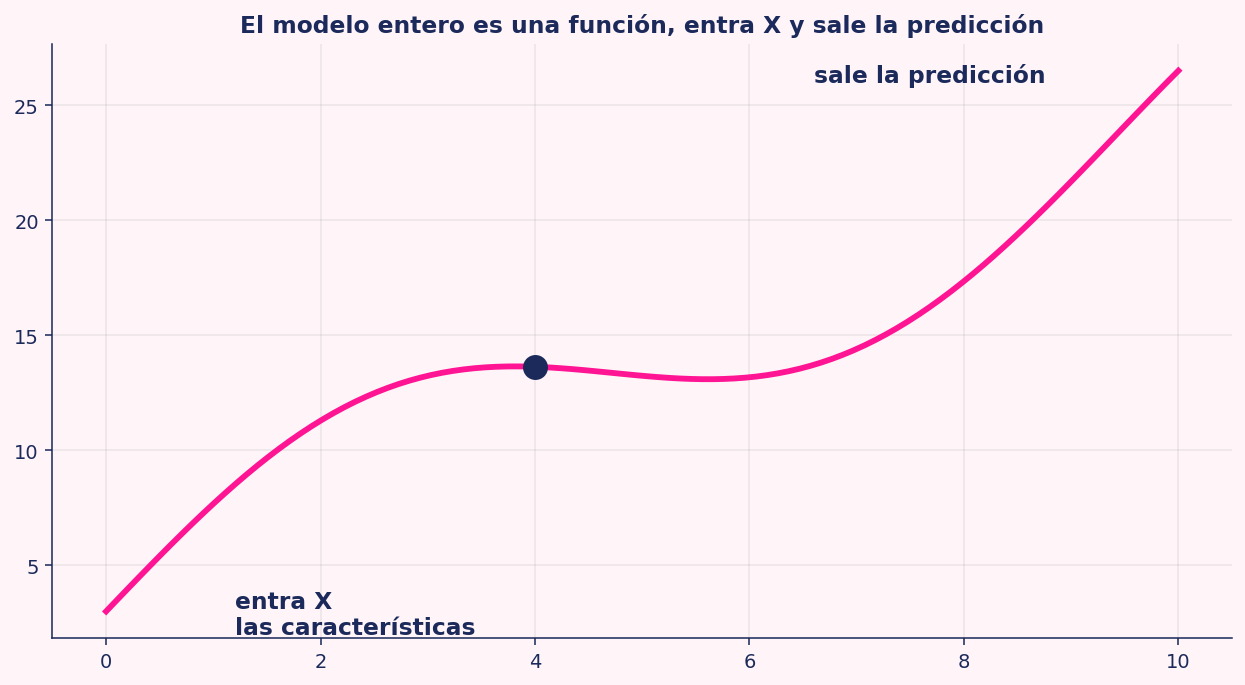

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;">🤔 <b>Por qué te sirve saberlo,</b> Cada fila del dataset es un vector, y cuando en la clase 4 veas al modelo multiplicar columnas por pesos, eso es álgebra lineal trabajando para ti.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


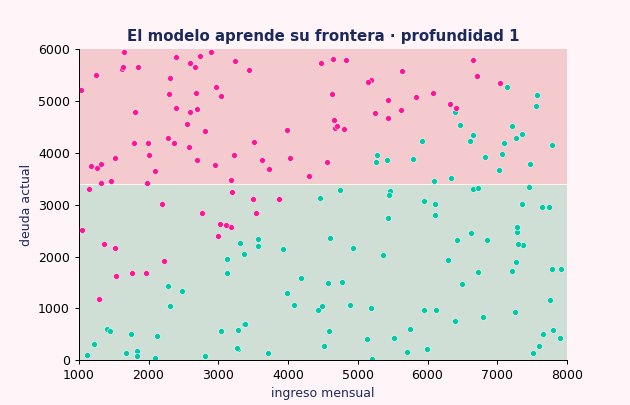

*Mira al modelo aprender su frontera a medida que gana profundidad.*


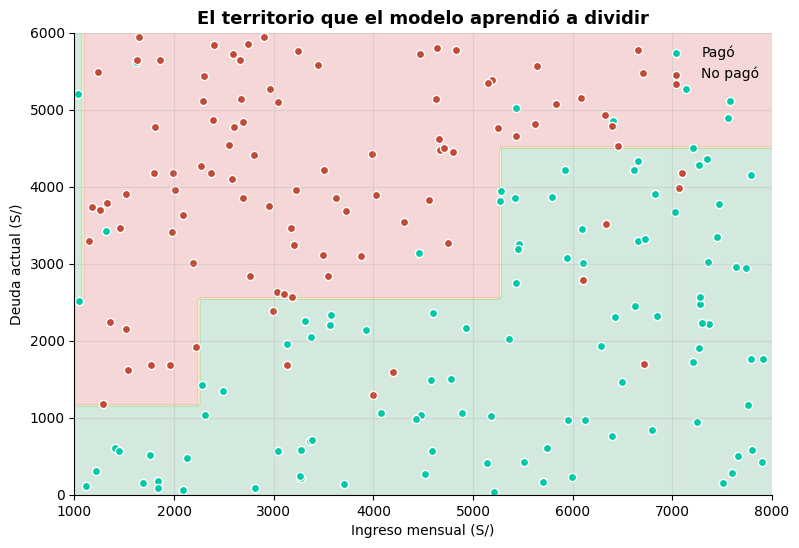

Las zonas de color son el criterio del modelo, verde aprueba, rojo desconfía


In [5]:
fig, ax = plt.subplots(figsize=(9, 6))

# Frontera de decisión, el mapa mental del modelo
xx, yy = np.meshgrid(np.linspace(1000, 8000, 200), np.linspace(0, 6000, 200))
Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.18, cmap="RdYlGn")

ax.scatter(ingreso[paga == 1], deuda[paga == 1], c="#00C9A7", s=35, label="Pagó", edgecolor="white")
ax.scatter(ingreso[paga == 0], deuda[paga == 0], c="#C34A36", s=35, label="No pagó", edgecolor="white")
ax.set_title("El territorio que el modelo aprendió a dividir")
ax.set_xlabel("Ingreso mensual (S/)")
ax.set_ylabel("Deuda actual (S/)")
ax.legend(frameon=False)
plt.show()
print("Las zonas de color son el criterio del modelo, verde aprueba, rojo desconfía")

## 6. ML en la vida real, casos que ya te tocan

- 🏦 Los bancos peruanos evalúan tu score crediticio con modelos como el de hoy
- 🛒 Rappi y los marketplaces predicen qué vas a querer comprar
- 🎬 Netflix y TikTok deciden qué mostrarte con modelos de recomendación
- 🏥 Hospitales priorizan pacientes prediciendo riesgo de complicación
- 📱 Tu cámara detecta caras, tu correo filtra spam, tu banco detecta fraude

Todo eso son variaciones de lo que acabas de ver, ejemplos históricos, patrones aprendidos, predicciones nuevas.


<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Cuál es la diferencia clave entre programar reglas y hacer ML?</b><ol type='a'><li>El lenguaje usado</li>
<li>✅ <b>En ML la máquina descubre los patrones desde ejemplos</b></li>
<li>ML no usa computadoras</li>
<li>No hay diferencia</li></ol><i>💡 En vez de escribir la lógica, le das datos y el modelo la aprende.</i><br>
<b>2. ¿Qué es el target?</b><ol type='a'><li>Una feature más</li>
<li>✅ <b>La variable que queremos predecir</b></li>
<li>El nombre del modelo</li>
<li>Un error</li></ol><i>💡 El target es la respuesta, en nuestro caso paga o no paga.</i><br>
<b>3. ¿Qué hace el método fit?</b><ol type='a'><li>Predice casos nuevos</li>
<li>✅ <b>Entrena el modelo con los ejemplos</b></li>
<li>Borra los datos</li>
<li>Grafica</li></ol><i>💡 fit es el momento del aprendizaje, el modelo ajusta sus patrones.</i><br>
<b>4. El deep learning es...</b><ol type='a'><li>Algo separado de la IA</li>
<li>✅ <b>Redes neuronales profundas dentro del ML</b></li>
<li>Solo para robots</li>
<li>Un lenguaje de programación</li></ol><i>💡 Es una familia de modelos dentro del machine learning.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>ML es aprender patrones desde datos en lugar de programar reglas</li>
<li>Features, target y ejemplos son los ingredientes de todo problema</li>
<li>fit entrena, predict responde casos nuevos</li>
<li>Ya viste tu primer modelo real dividiendo el territorio de decisión</li></ul>
<b>📝 Tarea de la semana,</b> anota tres decisiones repetitivas de tu trabajo o negocio y define para cada una cuáles serían sus features y su target.<br><b>➡️ Próxima clase,</b> aprendizaje supervisado y no supervisado, los dos grandes caminos del ML.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
acc = modelo.score(X, paga)
print(f'Accuracy {acc:.0%}, ¡a producción!')
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">El modelo se evaluó sobre los MISMOS datos con los que entrenó. Ese 98% no demuestra aprendizaje, demuestra memoria. El examen vale con datos que el modelo nunca vio, y esa idea es tan importante que le dedicamos la clase 6 completa.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [6]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. El modelo de PolliCreditos aprendió a aprobar créditos...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_0" value="0"> Con reglas que escribió un programador</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_0" value="1"> Mirando datos con sus respuestas</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_0" value="2"> Adivinando al azar</label><div id="qout1_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Qué es X en el problema de aprobación?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_1" value="0"> Solo el ingreso</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_1" value="1"> Las características que el modelo observa, ingreso y deuda</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_1" value="2"> La respuesta correcta</label><div id="qout1_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. Un modelo con accuracy de 98% evaluado sobre sus propios datos de entrenamiento...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_2" value="0"> Es un modelazo, a producción</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_2" value="1"> No demuestra nada todavía, hay que examinarlo con datos que no vio</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout1_2" value="2"> Es imposible</label><div id="qout1_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "datos m\u00e1s respuestas producen reglas aprendidas"], [1, "X son las pistas, y es la respuesta"], [1, "acu\u00e9rdate del examen sorpresa, esta idea vuelve en la clase 6"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout1_"+i+"\']:checked");
        var fb=document.getElementById("qout1_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

In [7]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **Machine learning** | la rama de la IA donde la computadora aprende patrones desde los datos en vez de recibir reglas escritas a mano |
| **Modelo** | el programa que resulta del entrenamiento, recibe datos nuevos y entrega predicciones |
| **X (features)** | las características que el modelo observa de cada fila, sus pistas |
| **y (target)** | la respuesta correcta que el modelo debe aprender a predecir |
| **Entrenamiento** | el proceso donde el modelo ajusta sus reglas internas mirando ejemplos con respuesta |

Este glosario se acumula clase a clase, en el proyecto final te llevas el diccionario completo del curso.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

En la clase 2 viene supervisado o no supervisado, el mapa que evita el 80% de los errores. Te espero en el siguiente video de la playlist.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>
